In [1]:
from qubic.lib.Qhdf5 import HDF5Dict
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from qubic.lib.QskySim import get_angular_profile

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

hwloc/linux: Ignoring PCI device with non-16bit domain.
Pass --enable-32bits-pci-domain to configure to support such devices
(warning: it would break the library ABI, don't enable unless really needed).


In [2]:
hdf5 = HDF5Dict()
data = hdf5.load_dict("parametric_d0_DB_test_convo_512/Dict/test_None.h5")
print(data["fwhm_rec"])

0.0042841330748209575


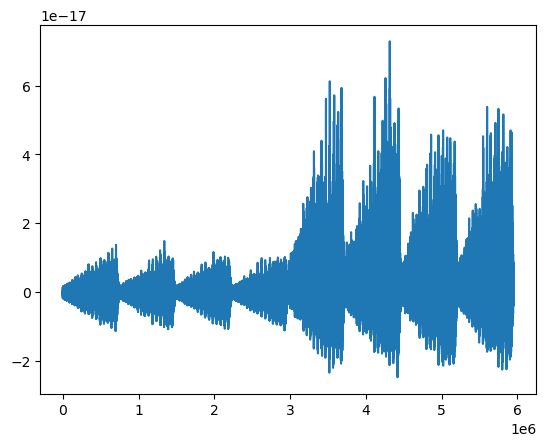

In [3]:
plt.plot(data["TOD_qubic"])

In [4]:
data.keys()

dict_keys(['convergence', 'fsky', 'fwhm_rec', 'index_beta', 'A', 'Atrue', 'G', 'TOD_external', 'TOD_qubic', 'all_gain', 'beta', 'beta_true', 'center', 'comps_name', 'coverage', 'fwhm_in', 'fwhm_out', 'g', 'gi', 'maps', 'maps_in', 'maps_in_convolved', 'maps_noise', 'nus_in', 'nus_out', 'parameters', 'qubic_dict', 'seenpix'])

In [5]:
data["TOD_external"].shape

(28311552,)

In [6]:
fwhm_in = data["fwhm_in"]
fwhm_out = data["fwhm_out"]
fwhm_rec = data["fwhm_rec"]
seenpix = data["seenpix"]

comp_maps_input = data["maps_in_convolved"].copy()
comp_maps_input = comp_maps_input
comp_maps_rec = data["maps"]
comp_maps_res = comp_maps_input - comp_maps_rec
# comp_maps_input[:, ~seenpix] = hp.UNSEEN
# comp_maps_rec[:,  ~seenpix] = hp.UNSEEN
# comp_maps_res[:, ~seenpix] = hp.UNSEEN

# for i in range(comp_maps_input.shape[0]):
#     C = HealpixConvolutionGaussianOperator(np.max(fwhm_in))
#     comp_maps_input[i] = C(comp_maps_input[i])
#     comp_maps_rec[i] = C(comp_maps_rec[i])

comp_maps_res = comp_maps_input - comp_maps_rec
center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]
print(comp_maps_input.shape)
print(fwhm_in)

(2, 3145728, 3)
[0.0075867  0.0071247  0.00669084 0.0062834  0.00517275 0.00485775
 0.00456193 0.00428413 0.00428413 0.00428413 0.00428413]


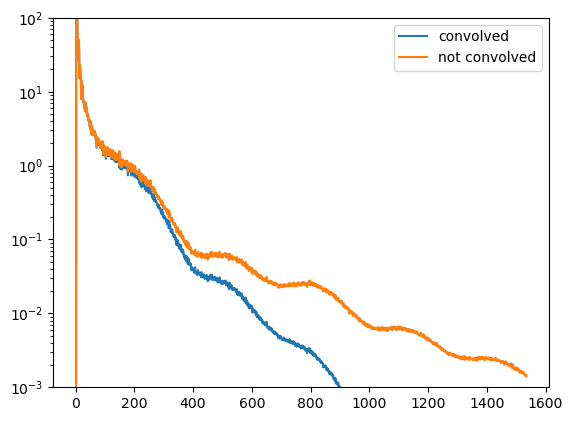

In [7]:
test_not_convolved = hp.anafast(data["maps_in"][0].T)
C = HealpixConvolutionGaussianOperator(np.min(fwhm_in))
# test_convolved = hp.anafast(C(data["maps_in"][0]).T)
test_convolved = hp.anafast(data["maps_in_convolved"][0].T)

plt.plot(test_convolved[0], label="convolved")
plt.plot(test_not_convolved[0], label="not convolved")
plt.yscale("log")
plt.ylim(1e-3, 1e2)
plt.legend()

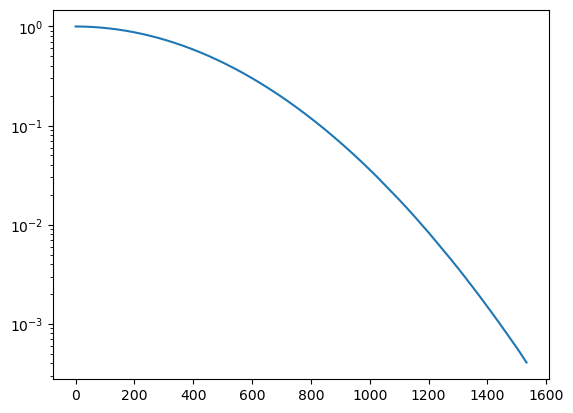

In [8]:
plt.plot(test_convolved[0, 2:]/test_not_convolved[0, 2:])
plt.yscale("log")

/tmp/ipykernel_61296/181903077.py:9: RuntimeWarning: invalid value encountered in divide
  test_ratio_cmb = test_input_cmb / test_rec_cmb
/tmp/ipykernel_61296/181903077.py:10: RuntimeWarning: invalid value encountered in divide
  test_ratio_dust = test_input_dust / test_rec_dust


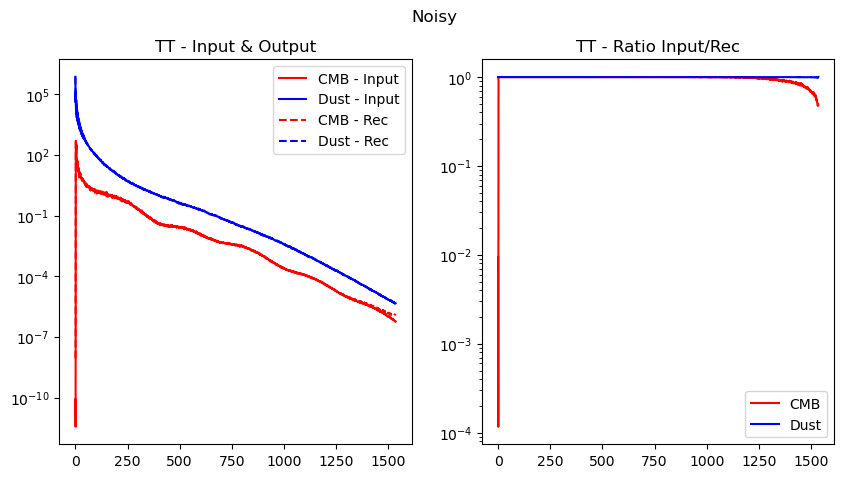

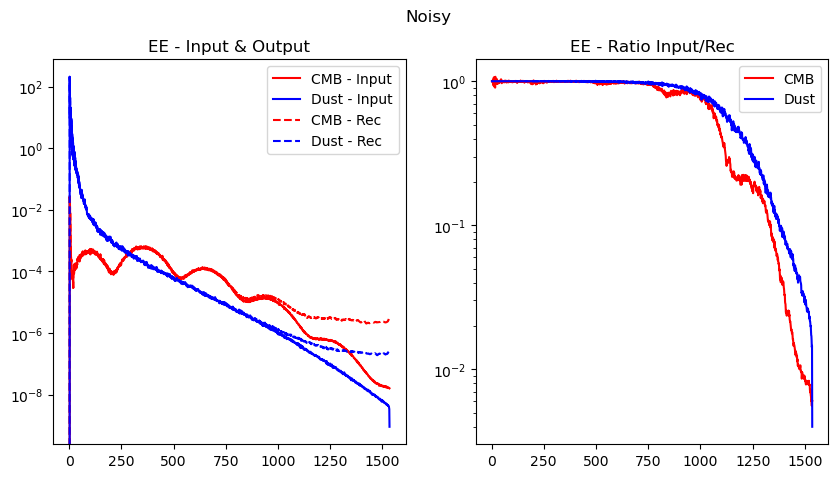

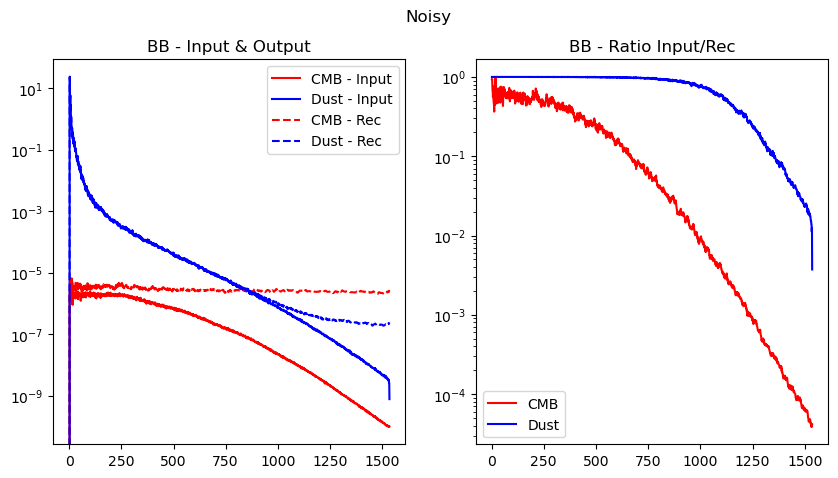

In [9]:
test_input_cmb = hp.anafast(comp_maps_input[0].T)
test_rec_cmb = hp.anafast(comp_maps_rec[0].T)
test_res_cmb = hp.anafast(comp_maps_res[0].T)

test_input_dust = hp.anafast(comp_maps_input[1].T)
test_rec_dust = hp.anafast(comp_maps_rec[1].T)
test_res_dust = hp.anafast(comp_maps_res[1].T)

test_ratio_cmb = test_input_cmb / test_rec_cmb
test_ratio_dust = test_input_dust / test_rec_dust

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("TT - Input & Output")
axes[0].plot(test_input_cmb[0], "r", label="CMB - Input")
axes[0].plot(test_input_dust[0], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[0], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[0], "--b", label="Dust - Rec")
# axes[0].plot(test_res_cmb[0], "-.r", label="CMB - Res")
# axes[0].plot(test_res_dust[0], "-.b", label="Dust - Res")
axes[0].set_yscale("log")

axes[1].set_title("TT - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[0], "r", label="CMB")
axes[1].plot(test_ratio_dust[0], "b", label="Dust")
axes[1].set_yscale("log")



axes[0].legend()
axes[1].legend()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("EE - Input & Output")
axes[0].plot(test_input_cmb[1], "r", label="CMB - Input")
axes[0].plot(test_input_dust[1], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[1], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[1], "--b", label="Dust - Rec")
axes[0].set_yscale("log")
axes[1].set_title("EE - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[1], "r", label="CMB")
axes[1].plot(test_ratio_dust[1], "b", label="Dust")
axes[1].set_yscale("log")
axes[0].legend()
axes[1].legend()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plt.suptitle(t="Noisy")
axes[0].set_title("BB - Input & Output")
axes[0].plot(test_input_cmb[2], "r", label="CMB - Input")
axes[0].plot(test_input_dust[2], "b", label="Dust - Input")
axes[0].plot(test_rec_cmb[2], "--r", label="CMB - Rec")
axes[0].plot(test_rec_dust[2], "--b", label="Dust - Rec")
axes[0].set_yscale("log")
axes[1].set_title("BB - Ratio Input/Rec")
axes[1].plot(test_ratio_cmb[2], "r", label="CMB")
axes[1].plot(test_ratio_dust[2], "b", label="Dust")
axes[1].set_yscale("log")
axes[0].legend()
axes[1].legend()

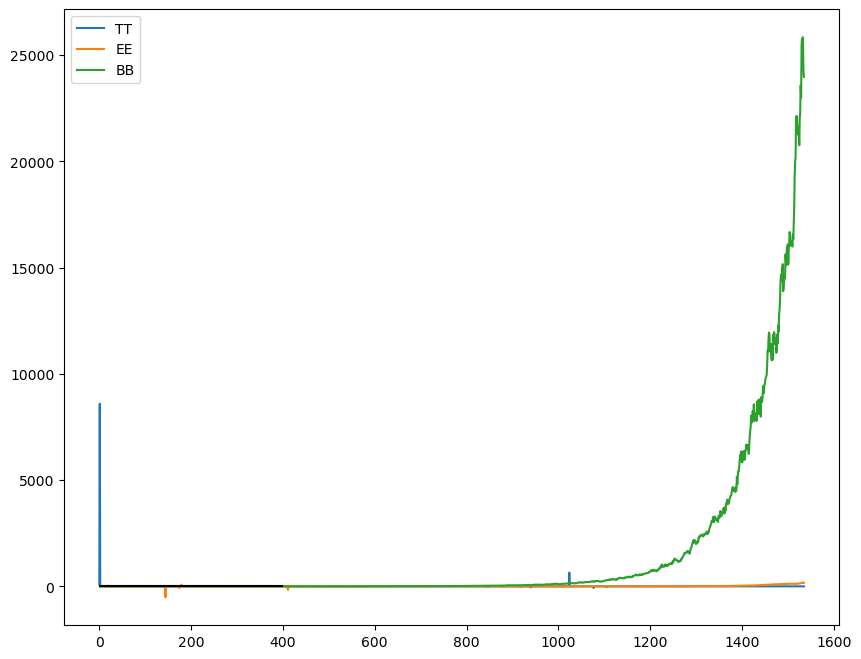

In [10]:
spec = ["TT", "EE","BB" ]
plt.figure(figsize=(10, 8))
test_noise_cmb = np.empty(test_res_cmb.shape)
for idx in range(3):
    test_noise_cmb[idx] = (test_ratio_cmb[idx] - 1) * test_input_cmb[idx]
    plt.plot(((test_noise_cmb[idx]- test_res_cmb[idx])/test_noise_cmb[idx]), label=spec[idx])
plt.hlines(0, 0, 400, "k")
plt.legend()
# plt.yscale(value="log")
# plt.ylim(-2e-4, 2e-4)

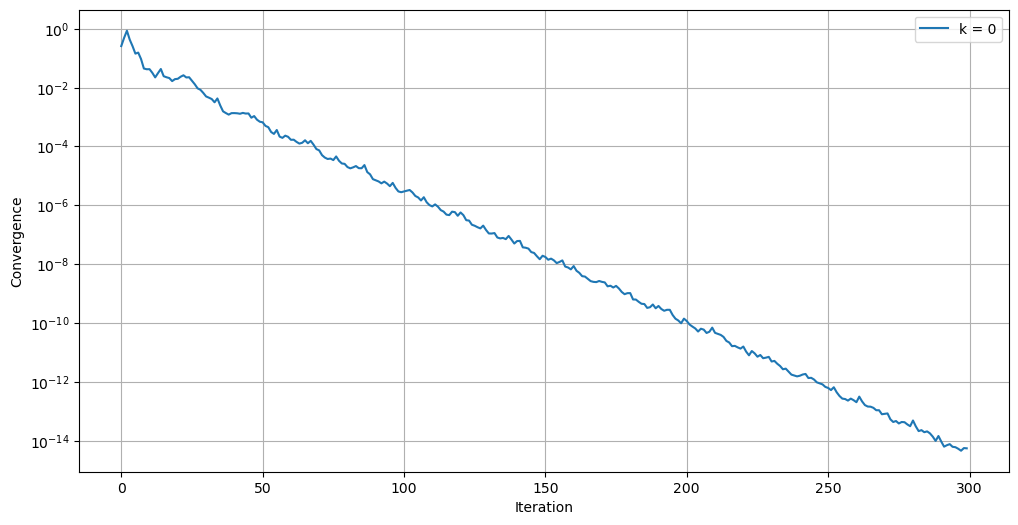

In [11]:
plt.figure(figsize=(12, 6))
for i in range(len(convergence)):
    plt.plot(convergence[i], label=f"k = {i}")

plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.legend()
plt.grid()
plt.yscale("log")
plt.legend()

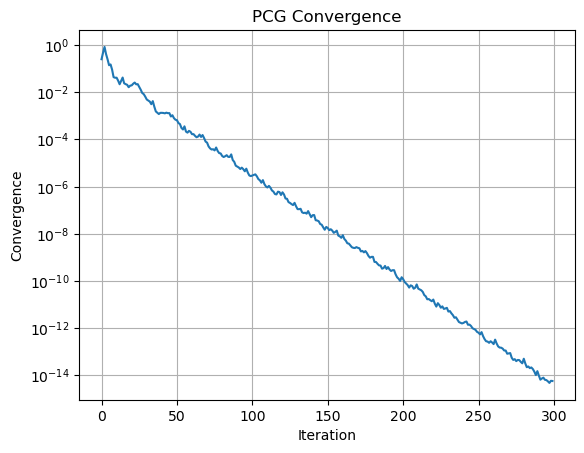

In [12]:
plt.plot(convergence[-1])
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.grid()
plt.show()

In [13]:
print("FWHM in: ", fwhm_in)
print("mean fwhm in: ", np.mean(fwhm_in))
print("FWHM out: ", fwhm_out)
print("FWHM rec: ", fwhm_rec)

FWHM in:  [0.0075867  0.0071247  0.00669084 0.0062834  0.00517275 0.00485775
 0.00456193 0.00428413 0.00428413 0.00428413 0.00428413]
mean fwhm in:  0.005401326835217469
FWHM out:  [0.00626132 0.00569276 0.00513941 0.00459644 0.00289888 0.00228997
 0.00156763 0.         0.         0.         0.        ]
FWHM rec:  0.0042841330748209575


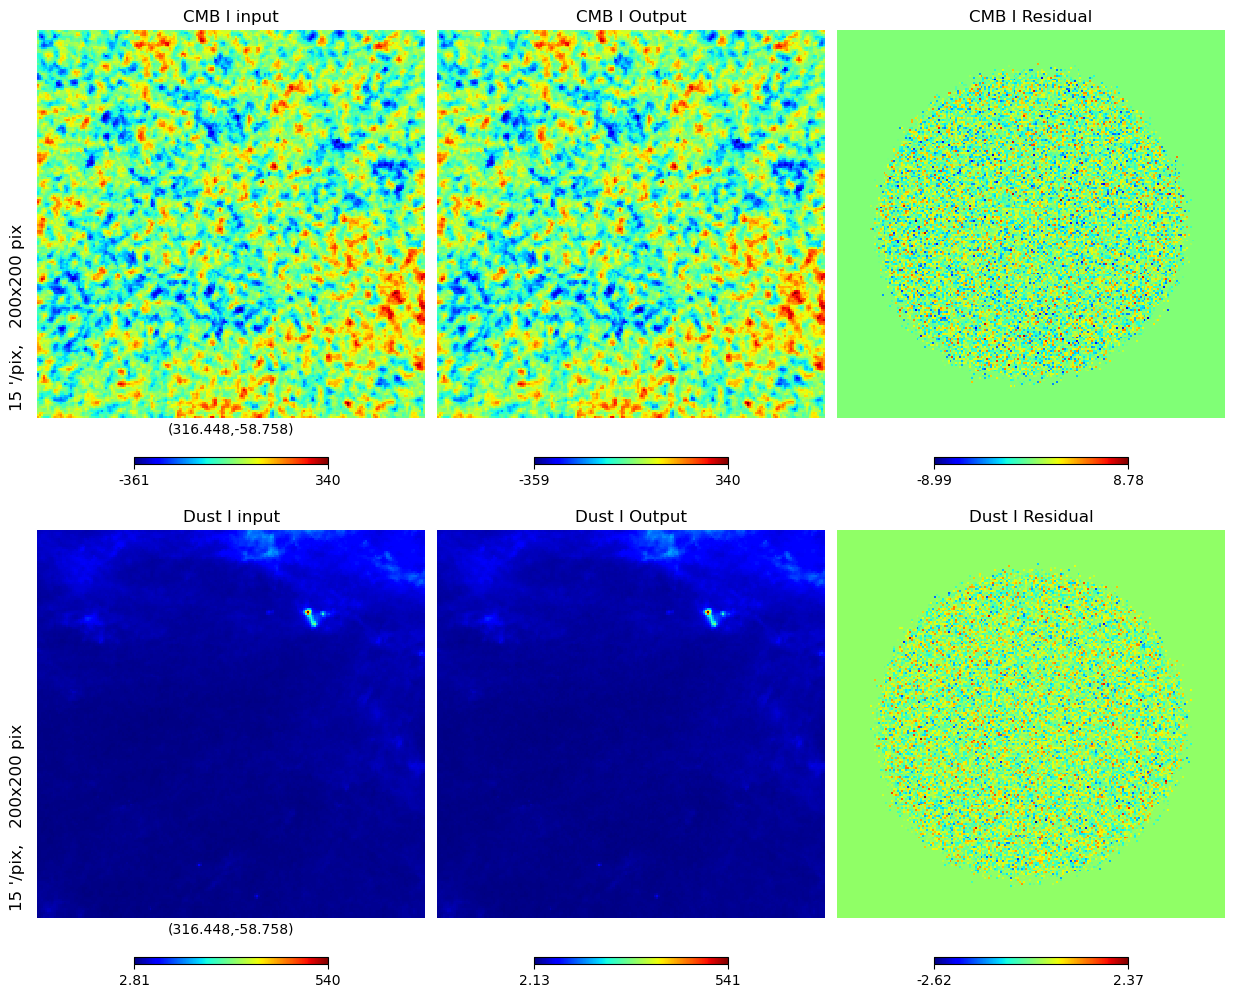

In [14]:
plt.figure(figsize=(12, 10))
name_comp = ["CMB", "Dust", "Synchrotron"]
STOKES = ["I", "Q", "U"]

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN


istk = 0
n = comp_maps_input.shape[0]
sigma_input = np.std(comp_maps_input[:, seenpix, istk], axis=0)
sigma_rec = np.std(comp_maps_rec[:, seenpix, istk], axis=0)
sigma_res = np.std(comp_maps_rec[:, seenpix, istk] - comp_maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

for icomp in range(n):
    C = HealpixConvolutionGaussianOperator(0)#fwhm_rec[icomp])
    hp.gnomview((C(comp_maps_input[icomp])[ :, istk]), rot=center,

                        reso=reso,
                        # notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                       
                        sub=(n, 3, k + 1))
    
    hp.gnomview((C(comp_maps_rec[icomp])[ :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
                        # min = - n * sigma_rec[icomp],
                        # max = n * sigma_rec[icomp],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(C(comp_maps_res[icomp])[ :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",  
                        cmap="jet",
               
                        sub=(n, 3, k + 3))
    k += 3

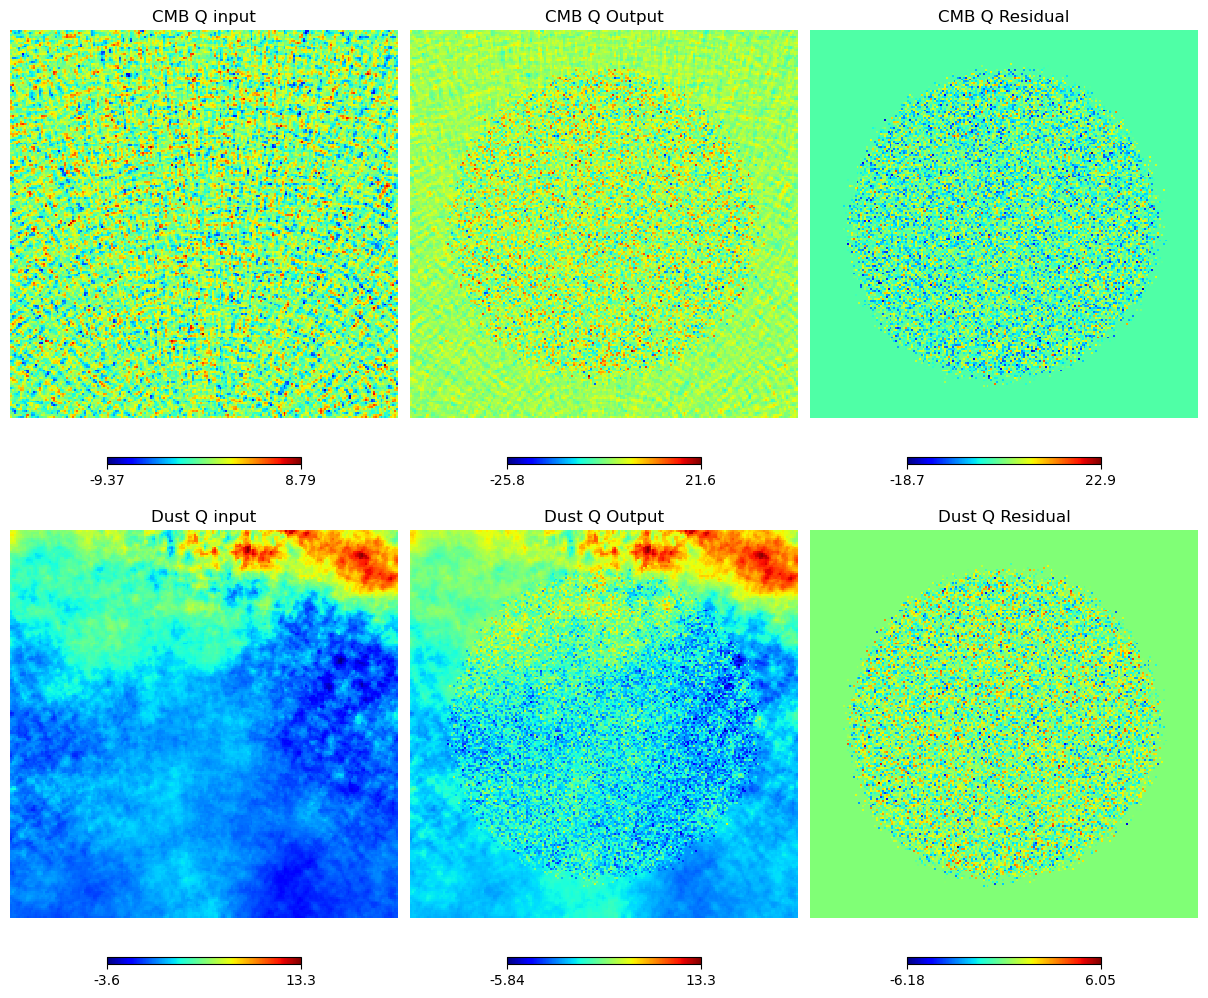

In [15]:
plt.figure(figsize=(12, 10))

# comp_maps_input[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_rec[:, ~seenpix, :] = hp.UNSEEN
# comp_maps_res[:, ~seenpix, :] = hp.UNSEEN

k = 0
istk = 1

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
    
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
         
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                   
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        sub=(n, 3, k + 3))
    k += 3

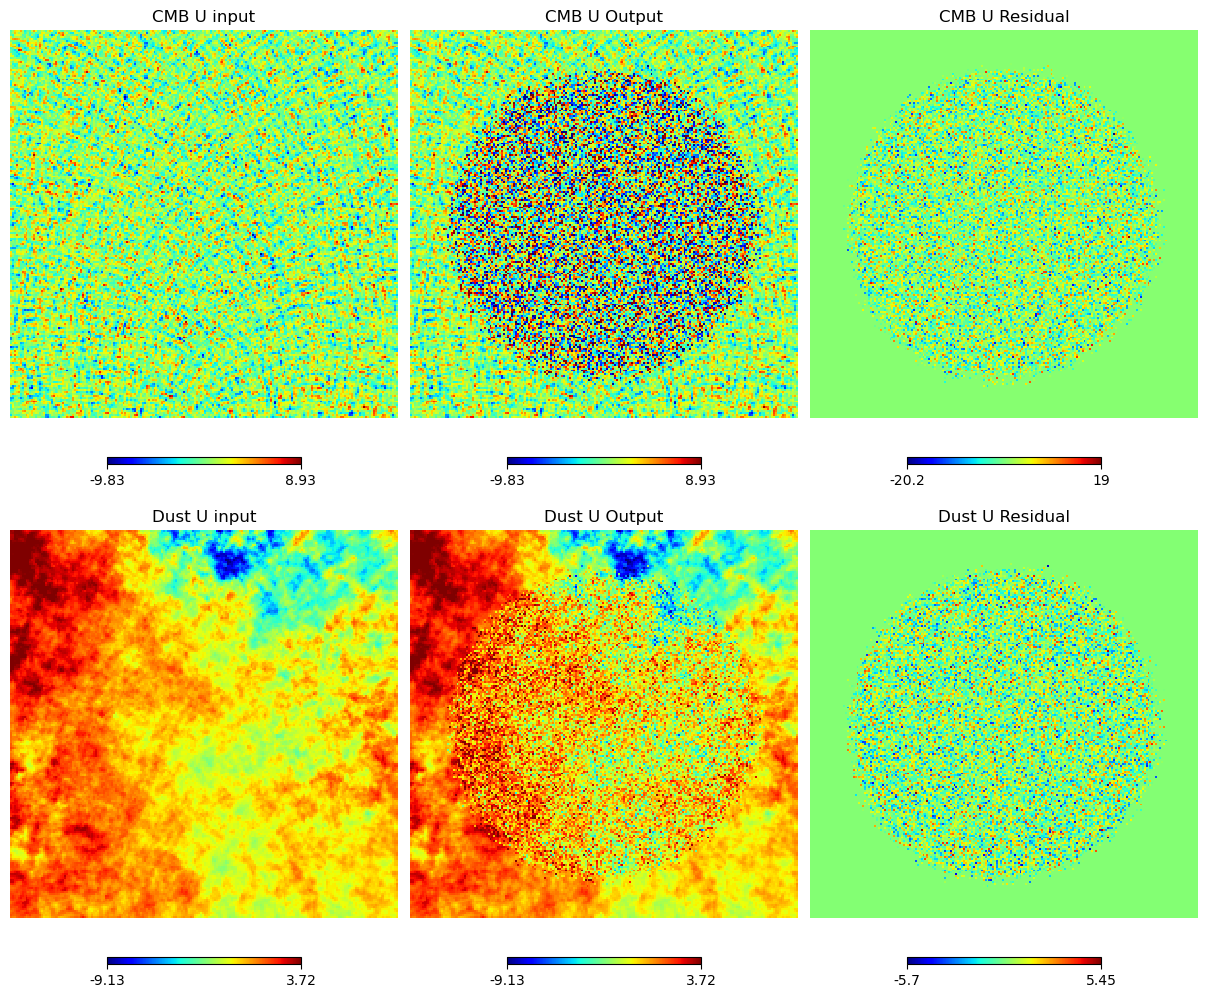

In [16]:
plt.figure(figsize=(12, 10))

min = np.min(comp_maps_input[:, seenpix], axis=1)
max = np.max(comp_maps_input[:, seenpix], axis=1)

k = 0
istk = 2

for icomp in range(n):
    hp.gnomview((comp_maps_input[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} input",  
                        cmap="jet",
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 1))
    
    hp.gnomview((comp_maps_rec[icomp, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Output",  
                        cmap="jet",
        # if self.preset_tools.params["PCG"]["fix_pixels_outside_patch"]:
        #     maps_external[:, ~self.preset_sky.seenpix_qubic, :] = 0
        #     self.TOD_external = _r.T(maps_external)

        #     self.seenpix_external = np.tile(self.preset_sky.seenpix_qubic, (maps_external.shape[0], 3, 1)).reshape(maps_external.shape)
                        min=min[icomp, istk],
                        max=max[icomp, istk],
                        sub=(n, 3, k + 2))
    
    hp.gnomview(comp_maps_res[icomp, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{name_comp[icomp]} {STOKES[istk]} Residual",
                        cmap="jet",
                        # min=min[icomp, istk],
                        # max=max[icomp, istk],
                        sub=(n, 3, k + 3))
    k += 3

(100,) (100,) (100,)


(array([ 0.085,  0.255,  0.425,  0.595,  0.765,  0.935,  1.105,  1.275,
         1.445,  1.615,  1.785,  1.955,  2.125,  2.295,  2.465,  2.635,
         2.805,  2.975,  3.145,  3.315,  3.485,  3.655,  3.825,  3.995,
         4.165,  4.335,  4.505,  4.675,  4.845,  5.015,  5.185,  5.355,
         5.525,  5.695,  5.865,  6.035,  6.205,  6.375,  6.545,  6.715,
         6.885,  7.055,  7.225,  7.395,  7.565,  7.735,  7.905,  8.075,
         8.245,  8.415,  8.585,  8.755,  8.925,  9.095,  9.265,  9.435,
         9.605,  9.775,  9.945, 10.115, 10.285, 10.455, 10.625, 10.795,
        10.965, 11.135, 11.305, 11.475, 11.645, 11.815, 11.985, 12.155,
        12.325, 12.495, 12.665, 12.835, 13.005, 13.175, 13.345, 13.515,
        13.685, 13.855, 14.025, 14.195, 14.365, 14.535, 14.705, 14.875,
        15.045, 15.215, 15.385, 15.555, 15.725, 15.895, 16.065, 16.235,
        16.405, 16.575, 16.745, 16.915]),
 array([2.90470192, 3.11770862, 2.74367415, 2.83995186, 3.10428112,
        2.84497145, 3.0053

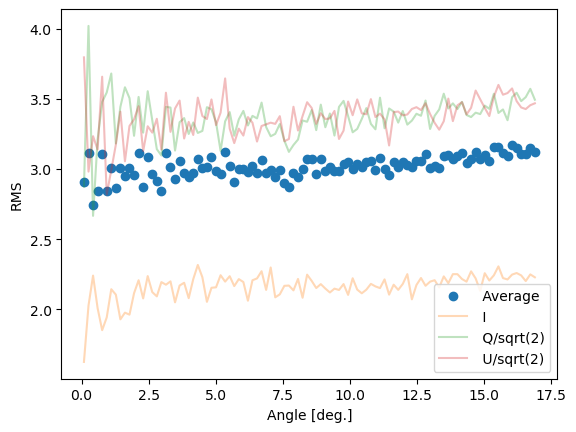

In [17]:
get_angular_profile(comp_maps_res[0], doplot=True, allstokes=True, nbins=100, thmax=17)

(100,) (100,) (100,)


(array([ 0.1,  0.3,  0.5,  0.7,  0.9,  1.1,  1.3,  1.5,  1.7,  1.9,  2.1,
         2.3,  2.5,  2.7,  2.9,  3.1,  3.3,  3.5,  3.7,  3.9,  4.1,  4.3,
         4.5,  4.7,  4.9,  5.1,  5.3,  5.5,  5.7,  5.9,  6.1,  6.3,  6.5,
         6.7,  6.9,  7.1,  7.3,  7.5,  7.7,  7.9,  8.1,  8.3,  8.5,  8.7,
         8.9,  9.1,  9.3,  9.5,  9.7,  9.9, 10.1, 10.3, 10.5, 10.7, 10.9,
        11.1, 11.3, 11.5, 11.7, 11.9, 12.1, 12.3, 12.5, 12.7, 12.9, 13.1,
        13.3, 13.5, 13.7, 13.9, 14.1, 14.3, 14.5, 14.7, 14.9, 15.1, 15.3,
        15.5, 15.7, 15.9, 16.1, 16.3, 16.5, 16.7, 16.9, 17.1, 17.3, 17.5,
        17.7, 17.9, 18.1, 18.3, 18.5, 18.7, 18.9, 19.1, 19.3, 19.5, 19.7,
        19.9]),
 array([0.93726822, 0.92844375, 0.87076572, 0.92414628, 0.90283772,
        0.87514964, 0.92064077, 0.87393299, 0.89295305, 0.88619624,
        0.83806638, 0.87047085, 0.93009227, 0.85719928, 0.84849758,
        0.86139306, 0.91336647, 0.89262663, 0.89033069, 0.91316175,
        0.87519989, 0.93159747, 0.89596664, 0.

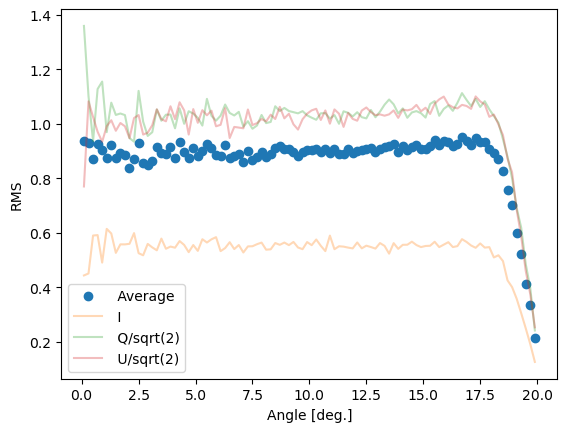

In [18]:
get_angular_profile(comp_maps_res[1], doplot=True, allstokes=True, nbins=100, thmax=20)

In [19]:
stop

NameError: name 'stop' is not defined

In [ ]:
icomp = 0

test_in = data["maps_in"][icomp].copy()
test_out = data["maps"][icomp].copy()

test_in[~seenpix, :] = 0
test_out[~seenpix, :] = 0

In [ ]:
def chi2_fwhm(fwhm):
    C = HealpixConvolutionGaussianOperator(fwhm)
    input_maps = C(test_in)
        
    return np.mean((test_out - input_maps) ** 2)

In [ ]:
list_chi2 = []

fwhm = np.logspace(np.log10(0.0001), np.log10(0.01), num=50)
for i in fwhm:
    list_chi2.append(chi2_fwhm(i))

list_chi2 = np.array(list_chi2)

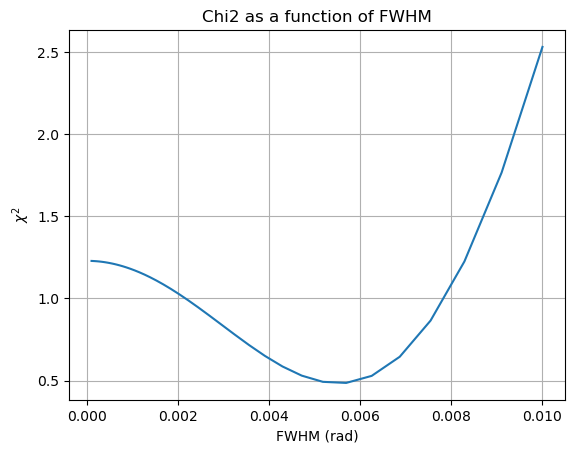

In [ ]:
plt.plot(fwhm, list_chi2)
plt.xlabel("FWHM (rad)")
plt.ylabel(r"$\chi^2$")
plt.title("Chi2 as a function of FWHM")
plt.grid()
plt.show()

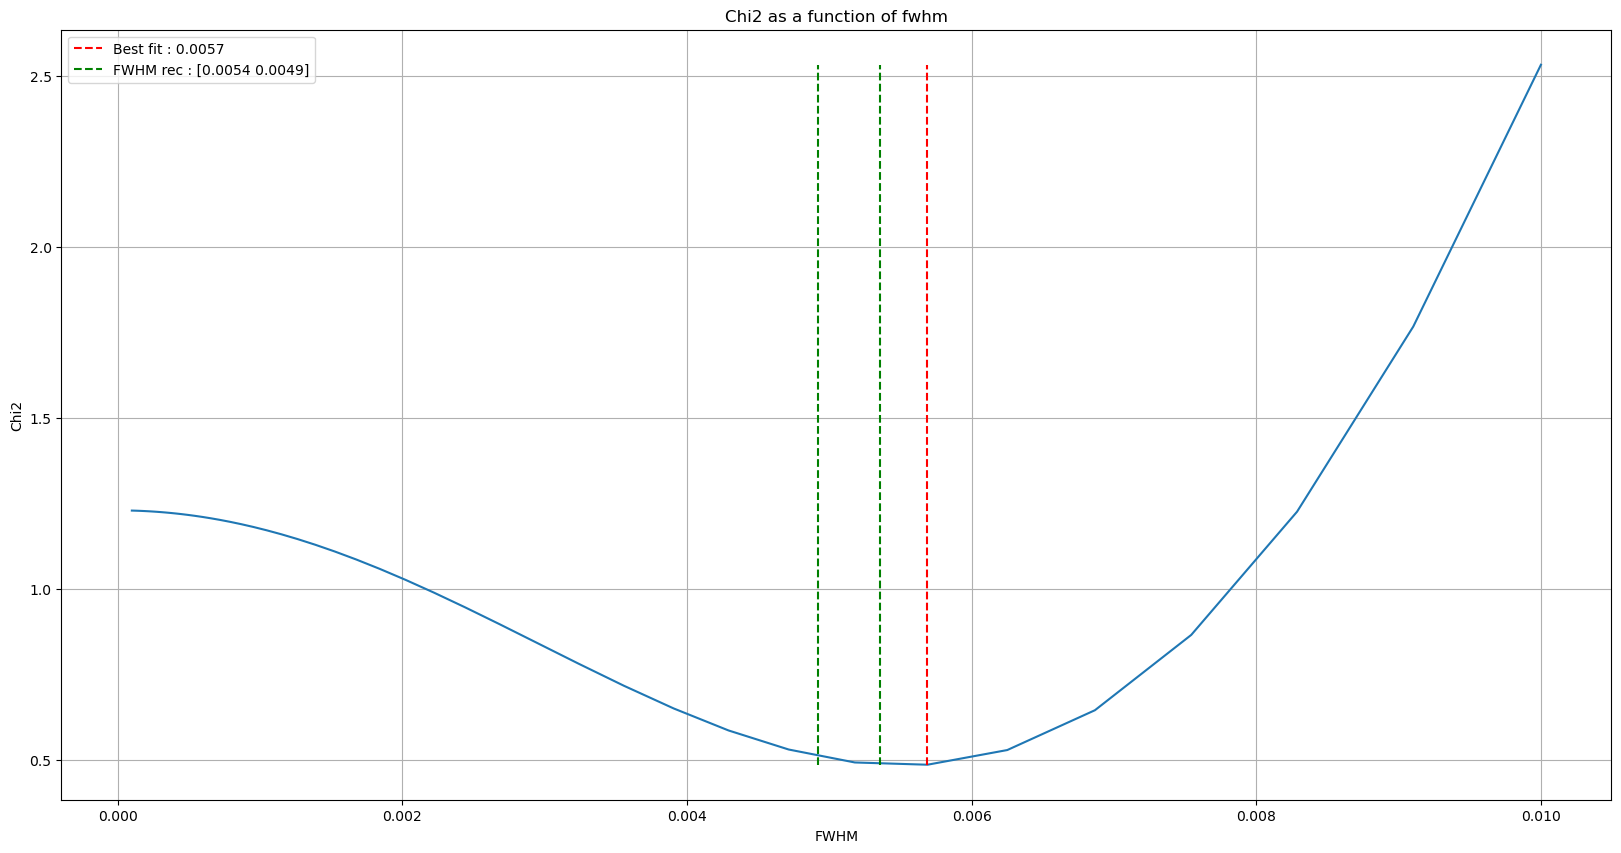

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(fwhm, list_chi2)
plt.vlines(fwhm[np.where(list_chi2 == np.min(list_chi2))[0][0]], np.min(list_chi2), np.max(list_chi2), color="red", linestyle="--", label=f"Best fit : {fwhm[np.where(list_chi2 == np.min(list_chi2))[0][0]].round(4)}")
plt.vlines(fwhm_rec, np.min(list_chi2), np.max(list_chi2), color="green", linestyle="--", label=f"FWHM rec : {fwhm_rec.round(4)}")
plt.title("Chi2 as a function of fwhm")
plt.xlabel("FWHM")
plt.ylabel("Chi2")
plt.grid()
plt.legend()
plt.show()

In [ ]:
hp.nside2resol(512, arcmin=True)

6.870972823634812